<a href="https://colab.research.google.com/github/leilacielok/market_basket_analysis/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithms for Massive Data - Market-Basket Analysis

In [1]:
import os
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from google.colab import userdata
from itertools import combinations
from collections import Counter, defaultdict


In [2]:
os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")


# SOSTITUIRE CON: Insert your Kaggle credentials before running
# os.environ['KAGGLE_USERNAME'] = "xxxx"
# os.environ['KAGGLE_KEY'] = "xxxx"

!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
!unzip -o -q imdb-dataset-of-top-1000-movies-and-tv-shows.zip -d imdb_data

print("Dataset downloaded and extracted.")

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
100% 175k/175k [00:00<00:00, 77.6MB/s]

Dataset downloaded and extracted.


In [3]:
csv_path = os.path.join(
    "imdb_data",
    "imdb_top_1000.csv"
)

df = pd.read_csv(csv_path)

In [4]:
# Global Parameters

MIN_SUPPORT_RATIO = 0.005
MIN_SUPPORT_COUNT = int(len(df) * MIN_SUPPORT_RATIO)

N_BUCKETS = 100

In [5]:
# Basket construction
STAR_COLS = ["Star1", "Star2", "Star3", "Star4"]

baskets = []

for _, row in df.iterrows():
    basket = []

    for col in STAR_COLS:
        actor = row[col]
        basket.append(actor)

    baskets.append(set(basket))

print("Number of baskets:", len(baskets))
print("Example basket:", baskets[0])

Number of baskets: 1000
Example basket: {'Morgan Freeman', 'William Sadler', 'Tim Robbins', 'Bob Gunton'}


# A-Priori Algorithm

In [6]:
def find_frequent_singletons(baskets, support_threshold):

    names2int = {}
    int2names = {}
    item_id = 0

    for basket in baskets:
        for item in basket:
            if item not in names2int:
                names2int[item] = item_id
                int2names[item_id] = item
                item_id += 1

    counts = [0] * len(names2int)

    for basket in baskets:
        for item in basket:
            item_integer = names2int[item]
            counts[item_integer] += 1

    frequent_items_table = [0] * len(counts)
    frequent_singletons = {}

    new_number = 1
    newint2name = {}

    for item_integer, count in enumerate(counts):
        if count >= support_threshold:
            frequent_items_table[item_integer] = new_number
            newint2name[new_number] = int2names[item_integer]
            frequent_singletons[frozenset([int2names[item_integer]])] = count
            new_number += 1

    return names2int, frequent_items_table, newint2name, frequent_singletons

In [7]:
def find_frequent_pairs_apriori(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    newint2name
):

    pair_counts = {}

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))

                pair_counts[pair] = pair_counts.get(pair, 0) + 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:
            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

    return frequent_pairs

# Park, Chen and Yu (PCY) Algorithm

In [8]:
def hash_pair(item1, item2, n_buckets):

    item1, item2 = sorted((item1, item2))
    hash_value = item1 * 31 + item2
    bucket = hash_value % n_buckets

    return bucket

In [9]:
def find_frequent_pairs_pcy(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    newint2name,
    n_buckets=N_BUCKETS,
    show_bucket_stats=False
):

    # FIRST PCY PASS
    # Count buckets for pairs of frequent items
    bucket_counts = [0] * n_buckets

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                bucket = hash_pair(item1, item2, n_buckets)

                bucket_counts[bucket] += 1

    # Bitmap of frequent buckets
    frequent_buckets = [
        count >= support_threshold
        for count in bucket_counts
    ]

    if show_bucket_stats:
      print(
          "Bucket average count:",
          round(sum(bucket_counts) / len(bucket_counts), 2))

      print(
          "Bucket max count:",
          max(bucket_counts))

      plt.hist(bucket_counts, bins=30)
      plt.xlabel("Bucket count")
      plt.ylabel("Number of buckets")
      plt.title("Distribution of bucket counts")

      plt.show()

    # SECOND PCY PASS
    # Count only pairs whose bucket is frequent
    pair_counts = {}

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(new_integer)

        for i in range(len(frequent_items_in_basket)):
            for j in range(i + 1, len(frequent_items_in_basket)):

                item1 = frequent_items_in_basket[i]
                item2 = frequent_items_in_basket[j]

                pair = tuple(sorted((item1, item2)))
                bucket = hash_pair(item1, item2, n_buckets)

                if frequent_buckets[bucket]:

                    pair_counts[pair] = pair_counts.get(pair, 0) + 1

    frequent_pairs = {}

    for pair, count in pair_counts.items():
        if count >= support_threshold:

            actor1 = newint2name[pair[0]]
            actor2 = newint2name[pair[1]]

            frequent_pairs[frozenset([actor1, actor2])] = count

    return frequent_pairs

# Finding triples
### Common block to both algorithms

In [10]:
def find_frequent_triples(
    baskets,
    support_threshold,
    names2int,
    frequent_items_table,
    frequent_pairs
):

    triple_counts = {}

    frequent_pair_sets = set(frequent_pairs.keys())

    for basket in baskets:

        frequent_items_in_basket = []

        for item in basket:
            old_integer = names2int[item]
            new_integer = frequent_items_table[old_integer]

            if new_integer != 0:
                frequent_items_in_basket.append(item)

        for triple in combinations(frequent_items_in_basket, 3):

            triple = frozenset(triple)

            if all(
                frozenset(pair) in frequent_pair_sets
                for pair in combinations(triple, 2)
            ):
                triple_counts[triple] = triple_counts.get(triple, 0) + 1

    frequent_triples = {}

    for triple, count in triple_counts.items():
        if count >= support_threshold:
            frequent_triples[triple] = count

    return frequent_triples

## Frequent itemsets

A-Priori Wrapper

In [11]:
def apriori(baskets, support_threshold):

    (
        names2int,
        frequent_items_table,
        newint2name,
        frequent_singletons
    ) = find_frequent_singletons(baskets, support_threshold)

    frequent_pairs = find_frequent_pairs_apriori(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        newint2name
    )

    frequent_triples = find_frequent_triples(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        frequent_pairs
    )

    frequent_itemsets = {}

    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs

    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

In [12]:
frequent_itemsets_apriori = apriori(
    baskets,
    MIN_SUPPORT_COUNT
)
frequent_itemsets_apriori

{1: {frozenset({'Morgan Freeman'}): 7,
  frozenset({'Diane Keaton'}): 6,
  frozenset({'Al Pacino'}): 13,
  frozenset({'Christian Bale'}): 11,
  frozenset({'Michael Caine'}): 9,
  frozenset({'Robert De Niro'}): 17,
  frozenset({'Viggo Mortensen'}): 5,
  frozenset({'Ian McKellen'}): 7,
  frozenset({'Bruce Willis'}): 7,
  frozenset({'Samuel L. Jackson'}): 6,
  frozenset({'Leonardo DiCaprio'}): 11,
  frozenset({'Brad Pitt'}): 12,
  frozenset({'Edward Norton'}): 7,
  frozenset({'Tom Hanks'}): 14,
  frozenset({'Clint Eastwood'}): 12,
  frozenset({'Joe Pesci'}): 6,
  frozenset({'Harrison Ford'}): 8,
  frozenset({'Jack Nicholson'}): 6,
  frozenset({'Matthew McConaughey'}): 6,
  frozenset({'Matt Damon'}): 11,
  frozenset({'Kevin Spacey'}): 5,
  frozenset({'Anthony Hopkins'}): 5,
  frozenset({'Alec Guinness'}): 5,
  frozenset({'Tatsuya Nakadai'}): 6,
  frozenset({'Toshirô Mifune'}): 7,
  frozenset({'James Stewart'}): 10,
  frozenset({'Joaquin Phoenix'}): 5,
  frozenset({'Scarlett Johansson'}): 9

PCY Wrapper

In [13]:
def pcy(baskets, support_threshold, n_buckets=100, show_bucket_stats=False):

    (
        names2int,
        frequent_items_table,
        newint2name,
        frequent_singletons
    ) = find_frequent_singletons(baskets, support_threshold)

    frequent_pairs = find_frequent_pairs_pcy(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        newint2name,
        n_buckets=n_buckets,
        show_bucket_stats=False
    )

    frequent_triples = find_frequent_triples(
        baskets,
        support_threshold,
        names2int,
        frequent_items_table,
        frequent_pairs
    )

    frequent_itemsets = {}

    frequent_itemsets[1] = frequent_singletons

    if frequent_pairs:
        frequent_itemsets[2] = frequent_pairs

    if frequent_triples:
        frequent_itemsets[3] = frequent_triples

    return frequent_itemsets

In [14]:
frequent_itemsets_pcy = pcy(
    baskets,
    MIN_SUPPORT_COUNT,
    n_buckets=N_BUCKETS,
    show_bucket_stats=True
)
frequent_itemsets_pcy

{1: {frozenset({'Morgan Freeman'}): 7,
  frozenset({'Diane Keaton'}): 6,
  frozenset({'Al Pacino'}): 13,
  frozenset({'Christian Bale'}): 11,
  frozenset({'Michael Caine'}): 9,
  frozenset({'Robert De Niro'}): 17,
  frozenset({'Viggo Mortensen'}): 5,
  frozenset({'Ian McKellen'}): 7,
  frozenset({'Bruce Willis'}): 7,
  frozenset({'Samuel L. Jackson'}): 6,
  frozenset({'Leonardo DiCaprio'}): 11,
  frozenset({'Brad Pitt'}): 12,
  frozenset({'Edward Norton'}): 7,
  frozenset({'Tom Hanks'}): 14,
  frozenset({'Clint Eastwood'}): 12,
  frozenset({'Joe Pesci'}): 6,
  frozenset({'Harrison Ford'}): 8,
  frozenset({'Jack Nicholson'}): 6,
  frozenset({'Matthew McConaughey'}): 6,
  frozenset({'Matt Damon'}): 11,
  frozenset({'Kevin Spacey'}): 5,
  frozenset({'Anthony Hopkins'}): 5,
  frozenset({'Alec Guinness'}): 5,
  frozenset({'Tatsuya Nakadai'}): 6,
  frozenset({'Toshirô Mifune'}): 7,
  frozenset({'James Stewart'}): 10,
  frozenset({'Joaquin Phoenix'}): 5,
  frozenset({'Scarlett Johansson'}): 9

## SON Algorithm

In [15]:
def son(baskets, support_count, n_chunks=4):

    chunk_size = int(np.ceil(len(baskets) / n_chunks))

    all_candidates = {
        1: set(),
        2: set(),
        3: set()
    }

    # Phase 1: local Apriori on chunks
    for i in range(n_chunks):
        chunk = baskets[i * chunk_size : (i + 1) * chunk_size]

        if len(chunk) == 0:
            continue

        local_support = int(np.ceil(support_count * len(chunk) / len(baskets)))

        local_frequent_itemsets = apriori(
            chunk,
            local_support
        )

        for k in [1, 2, 3]:
            all_candidates[k].update(
                local_frequent_itemsets.get(k, {}).keys()
            )

    # Phase 2: global counting
    candidate_counts = {
        1: defaultdict(int),
        2: defaultdict(int),
        3: defaultdict(int)
    }

    for basket in baskets:
        basket = set(basket)

        for k in [1, 2, 3]:
            for candidate in all_candidates[k]:
                if candidate.issubset(basket):
                    candidate_counts[k][candidate] += 1

    # Keep only globally frequent itemsets
    frequent_itemsets = {
        1: {},
        2: {},
        3: {}
    }

    for k in [1, 2, 3]:
        frequent_itemsets[k] = {
            itemset: count
            for itemset, count in candidate_counts[k].items()
            if count >= support_count
        }

    return frequent_itemsets

In [17]:
frequent_itemsets_son = son(
    baskets,
    MIN_SUPPORT_COUNT,
    n_chunks=4
)

frequent_itemsets_son

{1: {frozenset({'Morgan Freeman'}): 7,
  frozenset({'Al Pacino'}): 13,
  frozenset({'Diane Keaton'}): 6,
  frozenset({'Christian Bale'}): 11,
  frozenset({'Michael Caine'}): 9,
  frozenset({'Robert De Niro'}): 17,
  frozenset({'Viggo Mortensen'}): 5,
  frozenset({'Ian McKellen'}): 7,
  frozenset({'Bruce Willis'}): 7,
  frozenset({'Samuel L. Jackson'}): 6,
  frozenset({'Leonardo DiCaprio'}): 11,
  frozenset({'Edward Norton'}): 7,
  frozenset({'Brad Pitt'}): 12,
  frozenset({'Tom Hanks'}): 14,
  frozenset({'Clint Eastwood'}): 12,
  frozenset({'Joe Pesci'}): 6,
  frozenset({'Harrison Ford'}): 8,
  frozenset({'Jack Nicholson'}): 6,
  frozenset({'Matthew McConaughey'}): 6,
  frozenset({'Matt Damon'}): 11,
  frozenset({'Kevin Spacey'}): 5,
  frozenset({'Anthony Hopkins'}): 5,
  frozenset({'Alec Guinness'}): 5,
  frozenset({'Tatsuya Nakadai'}): 6,
  frozenset({'Toshirô Mifune'}): 7,
  frozenset({'James Stewart'}): 10,
  frozenset({'Joaquin Phoenix'}): 5,
  frozenset({'Scarlett Johansson'}): 9

## Scalability Experiment

In [20]:
support_ratios = [0.05, 0.01, 0.005, 0.002]

N_RUNS = 50
N_CHUNKS = 4

results = []

for ratio in support_ratios:

    support_count = int(len(baskets) * ratio)

    apriori_times = []
    pcy_times = []
    son_times = []

    for _ in range(N_RUNS):

      # APRIORI
      start = time.time()

      frequent_itemsets_apriori = apriori(
          baskets,
          support_count
      )

      apriori_times.append(time.time() - start)

      # PCY
      start = time.time()

      frequent_itemsets_pcy = pcy(
          baskets,
          support_count,
          n_buckets=N_BUCKETS,
          show_bucket_stats=False
      )

      pcy_times.append(time.time() - start)

      # SON
      start = time.time()

      frequent_itemsets_son = son(
          baskets,
          support_count,
          n_chunks=N_CHUNKS
      )

      son_times.append(time.time() - start)

    apriori_time = sum(apriori_times) / N_RUNS
    pcy_time = sum(pcy_times) / N_RUNS
    son_time = sum(son_times) / N_RUNS

    n_frequent_1 = len(frequent_itemsets_apriori.get(1, {}))
    n_frequent_2 = len(frequent_itemsets_apriori.get(2, {}))
    n_frequent_3 = len(frequent_itemsets_apriori.get(3, {}))

    total_itemsets = (
        n_frequent_1 +
        n_frequent_2 +
        n_frequent_3
    )

    results.append({
        "support_ratio": ratio,
        "support_count": support_count,
        "apriori_time": apriori_time,
        "pcy_time": pcy_time,
        "son_time": son_time,
        "frequent_1_itemsets": n_frequent_1,
        "frequent_2_itemsets": n_frequent_2,
        "frequent_3_itemsets": n_frequent_3,
        "total_itemsets": total_itemsets
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,support_ratio,support_count,apriori_time,pcy_time,son_time,frequent_1_itemsets,frequent_2_itemsets,frequent_3_itemsets,total_itemsets
0,0.050,50,0.0027,0.0033,0.0032,0,0,0,0
1,0.010,10,0.0026,0.0032,0.0117,9,0,0,9
2,0.005,5,0.0036,0.0045,0.0462,79,3,1,83
3,0.002,2,0.0077,0.0091,1.8331,641,121,25,787


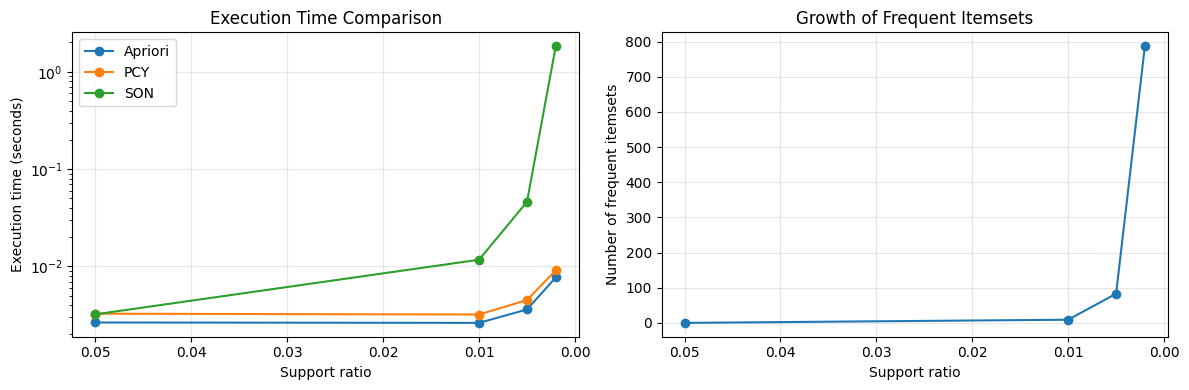

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Comparison of execution times

axes[0].plot(
    results_df["support_ratio"],
    results_df["apriori_time"],
    marker="o",
    label="Apriori"
)

axes[0].plot(
    results_df["support_ratio"],
    results_df["pcy_time"],
    marker="o",
    label="PCY"
)

axes[0].plot(
    results_df["support_ratio"],
    results_df["son_time"],
    marker="o",
    label="SON"
)

axes[0].set_yscale("log")
axes[0].invert_xaxis()
axes[0].set_xlabel("Support ratio")
axes[0].set_ylabel("Execution time (seconds)")
axes[0].set_title("Execution Time Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Number of frequent itemsets

axes[1].plot(
    results_df["support_ratio"],
    results_df["total_itemsets"],
    marker="o"
)

axes[1].invert_xaxis()
axes[1].set_xlabel("Support ratio")
axes[1].set_ylabel("Number of frequent itemsets")
axes[1].set_title("Growth of Frequent Itemsets")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Effect of the number of buckets for the PCY Algorithm
bucket_results = []

for n_buckets in [100, 500, 1000, 5000, 10000]:
    times = []

    for _ in range(N_RUNS):

        start = time.time()

        pcy(
            baskets,
            MIN_SUPPORT_COUNT,
            n_buckets=n_buckets,
            show_bucket_stats=False
        )

        times.append(time.time() - start)

    avg_time = sum(times) / N_RUNS

    bucket_results.append({
        "n_buckets": n_buckets,
        "pcy_time": avg_time
    })

bucket_results_df = pd.DataFrame(bucket_results)

bucket_results_df.round(4)

,n_buckets,pcy_time
0,100,0.0041
1,500,0.0042
2,1000,0.0037
3,5000,0.0038
4,10000,0.0041


In [24]:
# Effect of the number of chunks for the SON Algorithm

chunk_results = []

for n_chunks in [4, 10, 20]:
    times = []

    for _ in range(N_RUNS):

        start = time.time()

        son(
            baskets,
            MIN_SUPPORT_COUNT,
            n_chunks=n_chunks
        )

        times.append(time.time() - start)

    avg_time = sum(times) / N_RUNS

    chunk_results.append({
        "n_chunks": n_chunks,
        "son_time": avg_time
    })

chunk_results_df = pd.DataFrame(chunk_results)

chunk_results_df.round(4)

,n_chunks,son_time
0,4,0.0402
1,10,1.8356
2,20,1.8433
